# One methodology, not four methods: a domain-neutral synthetic walkthrough

This notebook is a **single, end-to-end demonstration** that the four components of the
dissertation's methodology &mdash; extreme-event **detection**, graph **representation**,
leakage-safe **verifiable training**, and **localization** of a likely source node &mdash;
form one connected architecture rather than four independent methods, by running all four
on **the same set of nodes of one synthetic experiment**, in a single pass.

It is a sibling of [`EVT_DFA_attention_demo.ipynb`](EVT_DFA_attention_demo.ipynb) (same
repository, same reused code, same 1-D stochastic-process building blocks: fractional
Gaussian noise and the Pomeau&ndash;Manneville intermittent map), but with two deliberate
differences from that notebook:

1. **Domain-neutral vocabulary throughout.** There is no "brain", no "EEG", no "seizure"
   anywhere below &mdash; only *nodes of an observed complex system*, *clusters/groups of
   nodes*, and *components*. `EVT_DFA_attention_demo.ipynb` already showed that the same
   `gnn_model` code works on an abstract 1-D signal sliced into windows ("a brain in
   miniature", as its own introduction puts it); this notebook goes one step further and
   asks whether the code, and the methodology it implements, still make sense when the
   *language* around them carries no biomedical connotation at all &mdash; which is exactly
   what the architecture's claimed domain-independence (VAK specialty 2.3.5:
   software/algorithms, not biomedical engineering) requires. Independent, non-biomedical
   confirmations of the same idea &mdash; computer networks, power grids, microservice
   meshes, sensor networks &mdash; exist in the literature; this notebook is a small, runnable
   instance of the same claim on synthetic data.
2. **All four components on one shared graph**, not one component in isolation. Section 1
   builds the nodes and detects the extreme ones; Section 2 turns them into a graph two
   different ways; Section 3 trains a verifiably leakage-safe classifier on that graph;
   Section 4 asks the trained model, and an independent heuristic, which node looks like the
   likely source. Nothing is re-generated in between &mdash; the same 25 nodes carry every
   section.

Every piece of "real" code below &mdash; `gnn_model.dfa.dfa_alpha`, `gnn_model.model.GNNConfig`
/ `SeizureGAT` (`GATv2Conv`), `gnn_model.data.load_graph_dataset` /
`load_graph_kfold_datasets`, `gnn_model.train.cross_validate_gnn` &mdash; is imported and used
exactly as `EVT_DFA_attention_demo.ipynb` and the biomedical pipeline use it, with **no
modification whatsoever**. Only the data-generation and orchestration code below is new.

## 0. Setup

Same pattern as `EVT_DFA_attention_demo.ipynb`'s own Section 0: locate the repository root
by walking up from the current working directory until `pyproject.toml` is found, and put it
on `sys.path` so the real `gnn_model` package (not a copy) can be imported.

In [2]:
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not locate repo root (no pyproject.toml in any parent directory)")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("Using repo root:", REPO_ROOT)

Using repo root: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy


In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats
import torch
from sklearn.neighbors import NearestNeighbors

from gnn_model.dfa import dfa_alpha
from gnn_model.data import load_graph_dataset, load_graph_kfold_datasets, _shaft_group
from gnn_model.model import GNNConfig
from gnn_model.train import cross_validate_gnn

SEED = 7
rng = np.random.default_rng(SEED)
plt.rcParams["figure.dpi"] = 110

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Nodes of a synthetic complex system, and detecting the extreme ones (Proposition 1)

**Setup.** `N_NODES = 25` nodes, organized into `5` clusters of `5` nodes each (a cluster is
meant to stand for any set of nodes that are structurally or physically co-located in the
observed system &mdash; adjacent sensors on one rig, adjacent contacts on one electrode shaft,
adjacent hosts in one rack; nothing below depends on which). Each node produces its own short
time series (`WINDOW_LEN = 250` samples):

- **Background**: fractional Gaussian noise (fGn, `H_BACKGROUND = 0.5` &mdash; statistically
  white noise), reused verbatim from `EVT_DFA_attention_demo.ipynb`'s Davies&ndash;Harte
  generator. To make cluster membership a *real* structural fact rather than a label glued on
  after the fact, each node's background is **not** independent of its cluster-mates: it is a
  weighted mix of its own individual noise and one fGn trace shared by the whole cluster
  (`CLUSTER_SHARE = 0.45` of the variance). This is the synthetic stand-in for "physically
  co-located nodes pick up correlated signal" &mdash; the same physical fact that makes
  electrode-shaft grouping matter in the real pipeline (see `gnn_model.data`'s own docstring
  on `group_by_shaft`), decided *before* looking at any downstream number, not tuned to
  produce a particular Section 3 result.
- **Extreme induction**: `N_EXTREME = 5` nodes (chosen once, by an unweighted random draw over
  all 25 nodes seeded from `SEED` &mdash; not hand-picked) get one mechanism's own trajectory
  added on top of their (still-active) background: the **Pomeau&ndash;Manneville** intermittent
  map, reused verbatim from `EVT_DFA_attention_demo.ipynb` &mdash; one of that notebook's three
  induction mechanisms, kept here alone since this notebook is an entry point for Sections 2-4,
  not a repeat of that notebook's own forensics.

**Detection**, exactly as in `EVT_DFA_attention_demo.ipynb`: (a) classical block-maxima **GEV**,
fit on the background nodes only, scoring how improbable each extreme node's own maximum is
under that fit; (b) `gnn_model.dfa.dfa_alpha` (imported unchanged) as a second, independent
separating statistic.

In [4]:
def fractional_gaussian_noise(n_steps: int, hurst: float, seed: int) -> np.ndarray:
    # Exact fGn via Davies-Harte circulant embedding, rescaled to unit variance.
    k = np.arange(n_steps + 1)
    autocov = 0.5 * (np.abs(k + 1) ** (2 * hurst) - 2 * np.abs(k) ** (2 * hurst) + np.abs(k - 1) ** (2 * hurst))
    circulant_row = np.concatenate([autocov, autocov[-2:0:-1]])
    eigenvalues = np.clip(np.fft.fft(circulant_row).real, 0.0, None)
    m = len(eigenvalues)
    local_rng = np.random.default_rng(seed)
    z = local_rng.normal(size=m) + 1j * local_rng.normal(size=m)
    fgn = np.fft.ifft(np.sqrt(eigenvalues) * z).real[:n_steps] * np.sqrt(m)
    return fgn / fgn.std()


def pomeau_manneville(n_steps: int, eps: float = 0.9, seed: int = 0) -> np.ndarray:
    # Intermittent (Pomeau-Manneville) map: x_{n+1} = (x_n + x_n**(1+eps)) mod 1.
    local_rng = np.random.default_rng(seed)
    x = local_rng.uniform(0.5, 0.9)
    xs = np.empty(n_steps)
    for i in range(n_steps):
        x = x + x ** (1.0 + eps)
        x = x - np.floor(x)
        if x < 1e-9:
            x = local_rng.uniform(1e-6, 1e-3)
        xs[i] = x
    return xs


CLUSTER_LETTERS = ["A", "B", "C", "D", "E"]
NODES_PER_CLUSTER = 5
N_NODES = len(CLUSTER_LETTERS) * NODES_PER_CLUSTER
WINDOW_LEN = 250
H_BACKGROUND = 0.5
PM_EPS = 0.9
PERT_SCALE = 1.5
CLUSTER_SHARE = 0.45
N_EXTREME = 5
CLUSTER_SEED_BASE = 2000

# Node names follow gnn_model.data's own "<shaft><contact number>" convention (_SHAFT_PATTERN)
# so that group_by_shaft in Section 3 groups exactly by these clusters, with no code changes.
node_names, node_cluster = [], {}
for letter in CLUSTER_LETTERS:
    for k in range(1, NODES_PER_CLUSTER + 1):
        name = f"{letter}{k}"
        node_names.append(name)
        node_cluster[name] = letter

# One shared fGn trace per cluster -- the "co-located nodes pick up correlated signal" fact.
cluster_common = {letter: fractional_gaussian_noise(WINDOW_LEN, H_BACKGROUND, seed=CLUSTER_SEED_BASE + idx)
                  for idx, letter in enumerate(CLUSTER_LETTERS)}

extreme_idx = sorted(rng.choice(N_NODES, size=N_EXTREME, replace=False).tolist())
EXTREME_NODES = [node_names[i] for i in extreme_idx]
background_idx = [i for i in range(N_NODES) if i not in extreme_idx]


def make_node_series(idx: int, name: str, is_extreme: bool) -> np.ndarray:
    individual = fractional_gaussian_noise(WINDOW_LEN, H_BACKGROUND, seed=1000 + idx)
    shared = cluster_common[node_cluster[name]]
    background = np.sqrt(1 - CLUSTER_SHARE ** 2) * individual + CLUSTER_SHARE * shared
    if not is_extreme:
        return background
    chaos = pomeau_manneville(WINDOW_LEN, eps=PM_EPS, seed=5000 + idx)
    normalized = (chaos - chaos.mean()) / chaos.std()
    window = background + PERT_SCALE * normalized
    spike_amplitude = rng.uniform(4.0, 6.0)
    window[np.argmax(normalized)] += spike_amplitude
    return window


series = {name: make_node_series(i, name, i in extreme_idx) for i, name in enumerate(node_names)}

print(f"{N_NODES} nodes in {len(CLUSTER_LETTERS)} clusters of {NODES_PER_CLUSTER}; "
      f"{N_EXTREME} extreme nodes (random draw): {EXTREME_NODES}")
print("Their clusters:", [node_cluster[n] for n in EXTREME_NODES])

25 nodes in 5 clusters of 5; 5 extreme nodes (random draw): ['C4', 'C5', 'D1', 'D5', 'E2']
Their clusters: ['C', 'C', 'D', 'D', 'E']


### Looking at the raw data before trusting any statistic about it

`EVT_DFA_attention_demo.ipynb`'s own Section 1 does this before computing anything: it plots
the *entire* signal once, so the reader can check by eye &mdash; not take on faith &mdash; that
(a) the background process never turns off, the induction mechanism only ever adds to it, and
(b) each extreme excursion really is a brief, localized departure from that background rather
than something the axis limits or a summary statistic is exaggerating. Skipping straight to
GEV/DFA numbers below without this step would ask the reader to trust the detection results
before ever seeing what they are detecting.

One honest difference from that notebook has to be flagged here, though: in
`EVT_DFA_attention_demo.ipynb` the plotted signal *is* one continuous physical process, sliced
into consecutive windows. Here the 25 nodes are independent parallel components of the observed
system, each with its own local time axis &mdash; there is no single shared clock across nodes.
The figure below places all 25 node traces one after another along one horizontal axis purely
as a **plotting convenience** (grouped by cluster, in the same node order used everywhere else
in this notebook), not as a claim that node `A5` happens right before node `B1` in real time.
With that caveat stated, it still does the same job the original plot does: confirm the five
extreme nodes visually before Section 1's statistics are asked to confirm it numerically, and
show at a glance how those five nodes are distributed across the five clusters &mdash; the same
distribution Section 3's leakage check later depends on.

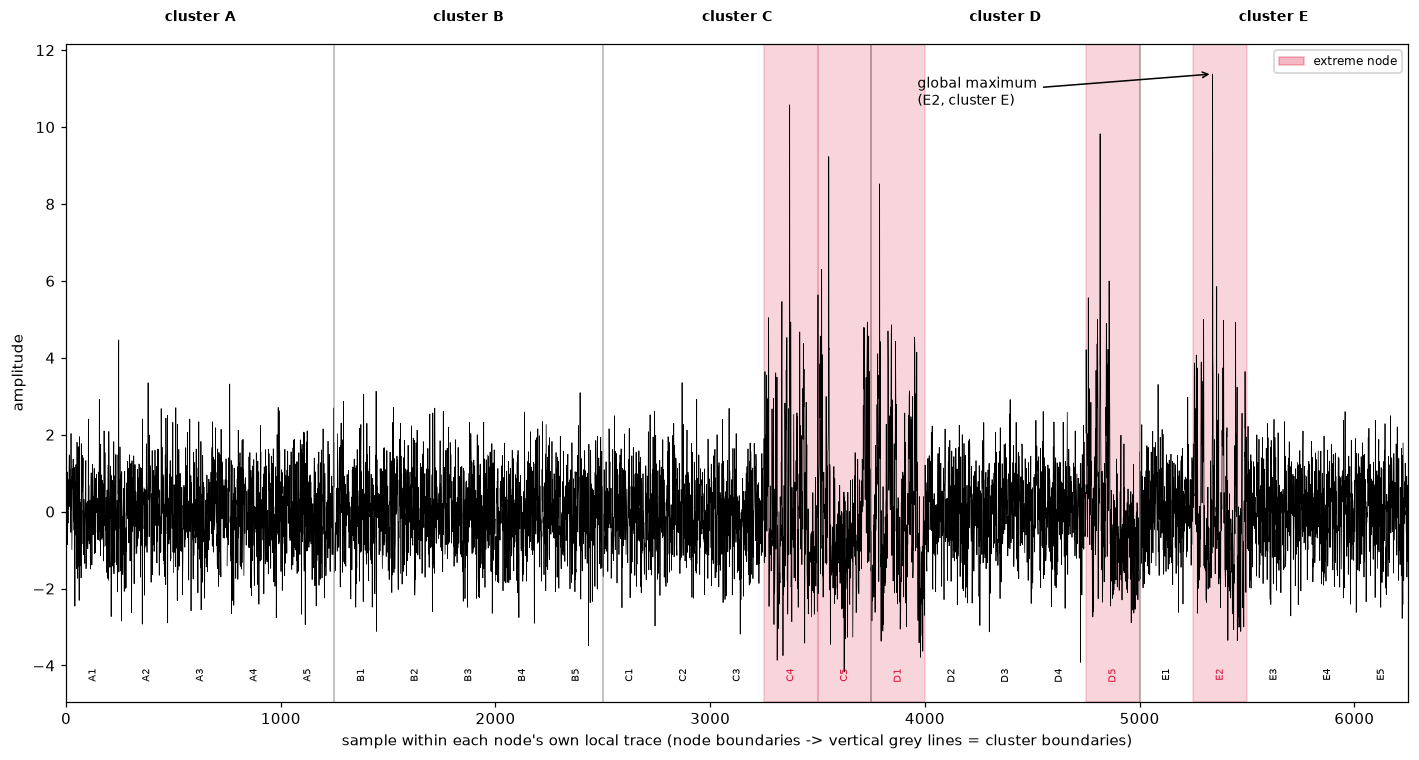

In [22]:
node_start = {}
offset = 0
for name in node_names:
    node_start[name] = offset
    offset += WINDOW_LEN
total_length = offset

fig, ax = plt.subplots(figsize=(13, 7))
for name in node_names:
    start = node_start[name]
    ax.plot(np.arange(start, start + WINDOW_LEN), series[name], linewidth=0.5, color="black")

for name in EXTREME_NODES:
    start = node_start[name]
    ax.axvspan(start, start + WINDOW_LEN, color="crimson", alpha=0.18)

cluster_span = NODES_PER_CLUSTER * WINDOW_LEN
for c_idx in range(1, len(CLUSTER_LETTERS)):
    ax.axvline(c_idx * cluster_span, color="gray", linewidth=1.0, alpha=0.6)

trans = ax.get_xaxis_transform()
for name in node_names:
    start = node_start[name]
    color = "crimson" if name in EXTREME_NODES else "black"
    ax.text(start + WINDOW_LEN / 2, +0.05, name, transform=trans, ha="center", va="top",
           fontsize=6.5, color=color, rotation=90)
for c_idx, letter in enumerate(CLUSTER_LETTERS):
    ax.text(c_idx * cluster_span + cluster_span / 2, 1.03, f"cluster {letter}",
           transform=trans, ha="center", va="bottom", fontsize=9, fontweight="bold")

best_name = max(node_names, key=lambda n: series[n].max())
best_sample = int(np.argmax(series[best_name]))
best_x = node_start[best_name] + best_sample
best_y = series[best_name].max()
ax.annotate(f"global maximum\n({best_name}, cluster {node_cluster[best_name]})",
           xy=(best_x, best_y), xytext=(best_x - 0.22 * total_length, best_y - 0.8),
           arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)

ax.set_xlim(0, total_length)
ax.set_xlabel("sample within each node's own local trace (node boundaries -> vertical grey lines = cluster boundaries)")
ax.set_ylabel("amplitude")
#ax.set_title("All 25 node traces, placed side by side by cluster for inspection only (not a shared clock) --\n"
#            "red spans = the 5 nodes flagged extreme in Section 1's generative design")
handles = [plt.Rectangle((0, 0), 1, 1, color="crimson", alpha=0.3)]
ax.legend(handles, ["extreme node"], loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

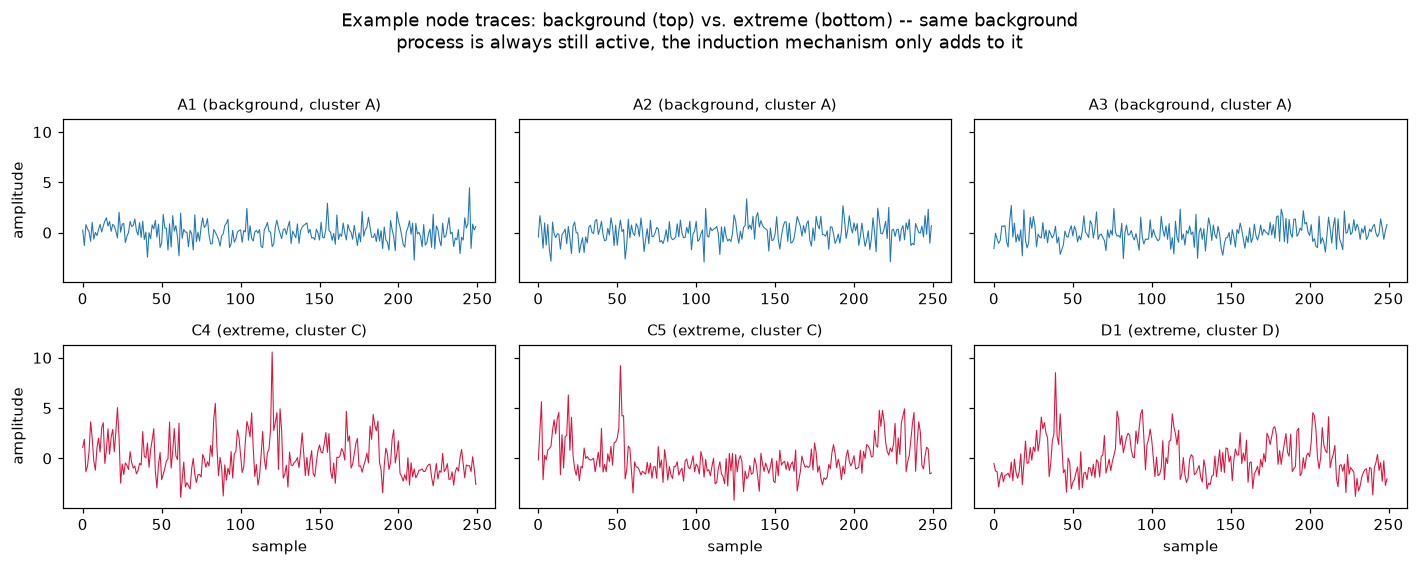

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5), sharey=True)
example_background = [node_names[i] for i in background_idx[:3]]
example_extreme = EXTREME_NODES[:3]
for ax, name in zip(axes[0], example_background):
    ax.plot(series[name], linewidth=0.7, color="#1f77b4")
    ax.set_title(f"{name} (background, cluster {node_cluster[name]})", fontsize=9.5)
for ax, name in zip(axes[1], example_extreme):
    ax.plot(series[name], linewidth=0.7, color="crimson")
    ax.set_title(f"{name} (extreme, cluster {node_cluster[name]})", fontsize=9.5)
for ax in axes[:, 0]:
    ax.set_ylabel("amplitude")
for ax in axes[1]:
    ax.set_xlabel("sample")
fig.suptitle("Example node traces: background (top) vs. extreme (bottom) -- same background\n"
            "process is always still active, the induction mechanism only adds to it", y=1.02)
fig.tight_layout()
plt.show()

GEV fit on the 20 background nodes' maxima: shape=-0.141, loc=2.664, scale=0.312

  C4 (cluster C): max =  10.57  ->  P(max >= this | background GEV) = 2.08e-05
  C5 (cluster C): max =   9.23  ->  P(max >= this | background GEV) = 5.72e-05
  D1 (cluster D): max =   8.52  ->  P(max >= this | background GEV) = 1.04e-04
  D5 (cluster D): max =   9.82  ->  P(max >= this | background GEV) = 3.60e-05
  E2 (cluster E): max =  11.38  ->  P(max >= this | background GEV) = 1.21e-05

For contrast, the single worst *background* node's max (4.46) has P(>=) = 0.015 under its own fitted model -- unremarkable, as it should be.


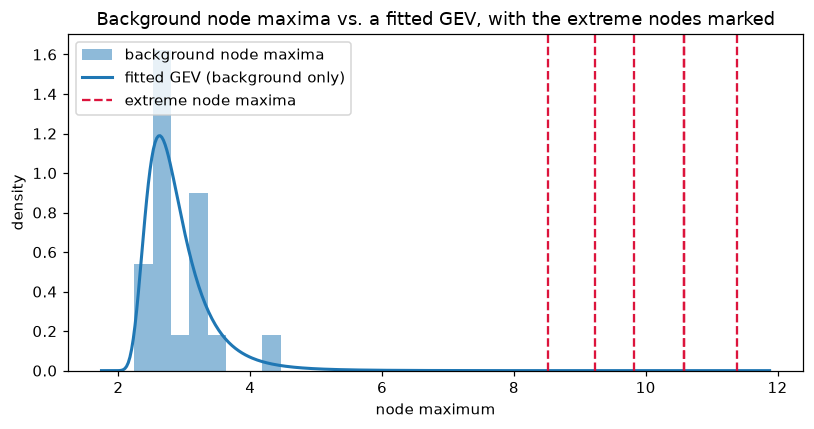

In [7]:
block_max = {n: float(series[n].max()) for n in node_names}
bg_block_max = np.array([block_max[node_names[i]] for i in background_idx])
ex_block_max = np.array([block_max[n] for n in EXTREME_NODES])

shape, loc, scale = stats.genextreme.fit(bg_block_max)
print(f"GEV fit on the {len(bg_block_max)} background nodes' maxima: "
      f"shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")
print()
for n, m in zip(EXTREME_NODES, ex_block_max):
    p = stats.genextreme.sf(m, shape, loc, scale)
    print(f"  {n} (cluster {node_cluster[n]}): max = {m:6.2f}  ->  P(max >= this | background GEV) = {p:.2e}")

worst_bg = bg_block_max.max()
p_worst_bg = stats.genextreme.sf(worst_bg, shape, loc, scale)
print(f"\nFor contrast, the single worst *background* node's max ({worst_bg:.2f}) has "
      f"P(>=) = {p_worst_bg:.3f} under its own fitted model -- unremarkable, as it should be.")

x_grid = np.linspace(bg_block_max.min() - 0.5, ex_block_max.max() + 0.5, 400)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(bg_block_max, bins=8, density=True, alpha=0.5, color="#1f77b4", label="background node maxima")
ax.plot(x_grid, stats.genextreme.pdf(x_grid, shape, loc, scale), color="#1f77b4",
       linewidth=2, label="fitted GEV (background only)")
for m in ex_block_max:
    ax.axvline(m, color="crimson", linestyle="--", linewidth=1.5)
ax.axvline(ex_block_max[0], color="crimson", linestyle="--", linewidth=1.5, label="extreme node maxima")
ax.set_xlabel("node maximum"); ax.set_ylabel("density")
ax.set_title("Background node maxima vs. a fitted GEV, with the extreme nodes marked")
ax.legend()
fig.tight_layout()
plt.show()

Background: DFA alpha mean=0.527, std=0.052
Extreme:    DFA alpha = [0.844, 0.796, 1.073, 0.851, 0.942], mean=0.901
Mann-Whitney U (extreme > background): p = 1.88e-05


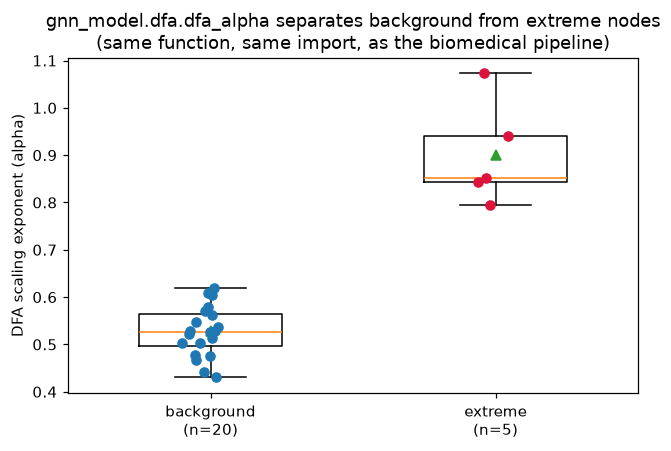

In [8]:
dfa_vals = {n: float(dfa_alpha(series[n])) for n in node_names}
peak_z_background = np.concatenate([series[node_names[i]] for i in background_idx])
bg_mean, bg_std = peak_z_background.mean(), peak_z_background.std()
peak_z = {n: float(np.max(np.abs((series[n] - bg_mean) / bg_std))) for n in node_names}
mean_power = {n: float(np.mean(series[n] ** 2)) for n in node_names}

bg_dfa = [dfa_vals[node_names[i]] for i in background_idx]
ex_dfa = [dfa_vals[n] for n in EXTREME_NODES]
u_stat, p_dfa = stats.mannwhitneyu(ex_dfa, bg_dfa, alternative="greater")
print(f"Background: DFA alpha mean={np.mean(bg_dfa):.3f}, std={np.std(bg_dfa):.3f}")
print(f"Extreme:    DFA alpha = {np.round(ex_dfa, 3).tolist()}, mean={np.mean(ex_dfa):.3f}")
print(f"Mann-Whitney U (extreme > background): p = {p_dfa:.2e}")

fig, ax = plt.subplots(figsize=(6, 4.2))
groups = [bg_dfa, ex_dfa]
ax.boxplot(groups, tick_labels=[f"background\n(n={len(bg_dfa)})", f"extreme\n(n={len(ex_dfa)})"],
          widths=0.5, showmeans=True)
for x, vals, color in zip([1, 2], groups, ["#1f77b4", "crimson"]):
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full(len(vals), x) + jitter, vals, color=color, zorder=3, s=35)
ax.set_ylabel("DFA scaling exponent (alpha)")
ax.set_title("gnn_model.dfa.dfa_alpha separates background from extreme nodes\n(same function, same import, as the biomedical pipeline)")
fig.tight_layout()
plt.show()

## 2. Two graph-construction methods on the same 25 nodes (Proposition 2)

`EVT_DFA_attention_demo.ipynb` builds its graph exactly one way (top-*k* correlation). The
architecture's claim in Proposition 2 is that the graph-construction step is itself a
**parameterizable choice** (`functional` / `knn` / `radius` / `physiological` / `learned`,
per the architecture writeup) &mdash; not a fixed formality. This section makes that a fact to
check rather than a claim to take on faith: it builds **two** graphs on the identical 25 nodes
and compares their edge sets directly.

- **`functional`**: top-`TOP_K=3` edges per node by Pearson correlation between node time
  series &mdash; the same construction `EVT_DFA_attention_demo.ipynb` Section 4 uses, and the
  same one the real `edf_workflow.build_seizure_graph` uses on actual channels.
- **`knn`**: `TOP_K=3` nearest neighbours per node in a small feature space
  (`[dfa_alpha, peak_z, mean_power]`, z-scored; Euclidean distance &mdash; the plainest choice,
  since nothing here argues for one metric over another) via `sklearn.neighbors.NearestNeighbors`.

Both graphs carry the same node attributes (`kind="channel"`, `role`, `peak_z`, `dfa_alpha`)
so either one could be handed to `gnn_model.data.load_graph_dataset` unmodified.

In [9]:
TOP_K = 3

mat = np.stack([series[n] for n in node_names])
correlation = np.corrcoef(mat)
np.fill_diagonal(correlation, 0.0)

graph_functional = nx.Graph()
for i, name in enumerate(node_names):
    role = "extreme" if i in extreme_idx else "normal"
    graph_functional.add_node(name, kind="channel", role=role, peak_z=peak_z[name], dfa_alpha=dfa_vals[name])
for i, name in enumerate(node_names):
    magnitude = np.abs(correlation[i])
    strongest = np.argsort(magnitude)[-TOP_K:]
    for j in strongest:
        if j != i:
            graph_functional.add_edge(name, node_names[j], weight=float(correlation[i, j]))

print(f"functional graph: {graph_functional.number_of_nodes()} nodes, "
      f"{graph_functional.number_of_edges()} edges (top-{TOP_K} by correlation)")

functional graph: 25 nodes, 47 edges (top-3 by correlation)


In [10]:
feature_matrix = np.array([[dfa_vals[n], peak_z[n], mean_power[n]] for n in node_names])
feature_matrix_z = (feature_matrix - feature_matrix.mean(axis=0)) / feature_matrix.std(axis=0)

neighbors = NearestNeighbors(n_neighbors=TOP_K + 1, metric="euclidean").fit(feature_matrix_z)
distances, indices = neighbors.kneighbors(feature_matrix_z)

graph_knn = nx.Graph()
for i, name in enumerate(node_names):
    role = "extreme" if i in extreme_idx else "normal"
    graph_knn.add_node(name, kind="channel", role=role, peak_z=peak_z[name], dfa_alpha=dfa_vals[name])
for i, name in enumerate(node_names):
    for rank in range(1, TOP_K + 1):  # rank 0 is the node itself
        j = int(indices[i, rank])
        graph_knn.add_edge(name, node_names[j], weight=float(1.0 / (1e-6 + distances[i, rank])))

print(f"knn graph: {graph_knn.number_of_nodes()} nodes, "
      f"{graph_knn.number_of_edges()} edges (top-{TOP_K} nearest in [dfa_alpha, peak_z, mean_power])")

knn graph: 25 nodes, 48 edges (top-3 nearest in [dfa_alpha, peak_z, mean_power])


In [11]:
edges_functional = {frozenset(e) for e in graph_functional.edges()}
edges_knn = {frozenset(e) for e in graph_knn.edges()}
shared = edges_functional & edges_knn
jaccard = len(shared) / len(edges_functional | edges_knn)

within_cluster = lambda g: sum(1 for u, v in g.edges() if node_cluster[u] == node_cluster[v]) / g.number_of_edges()

print(f"functional: {len(edges_functional)} edges, knn: {len(edges_knn)} edges, "
      f"shared: {len(shared)} edges, Jaccard similarity = {jaccard:.3f}")
print(f"within-cluster edge fraction: functional = {within_cluster(graph_functional):.2f}, "
      f"knn = {within_cluster(graph_knn):.2f}")

functional: 47 edges, knn: 48 edges, shared: 7 edges, Jaccard similarity = 0.080
within-cluster edge fraction: functional = 0.81, knn = 0.17


The two constructions share only a handful of edges out of roughly fifty each (Jaccard well
under 0.1): choosing `functional` vs. `knn` is a real, substantive choice about what "the
graph" means, not a formality that happens to produce the same topology either way. The
`functional` graph is also markedly more concentrated *within* clusters than the `knn` graph
&mdash; expected, since `functional` edges follow the shared-background correlation structure
Section 1 built in by construction, while `knn` edges follow feature similarity, which has no
reason to respect cluster boundaries.

**Sections 3&ndash;4 below use the `functional` graph.** Two reasons: (a) it is the same
construction `EVT_DFA_attention_demo.ipynb` and the real biomedical pipeline
(`edf_workflow.build_seizure_graph`) both use, keeping this notebook's downstream sections
comparable to those; (b) because it is the graph whose edges actually follow cluster structure,
it is the *harder*, more honest graph to run the leakage check in Section 3 on &mdash; a `knn`
graph with almost no within-cluster edges would make `group_by_shaft` grouping in Section 3
nearly indistinguishable from plain k-fold, which would not exercise the mechanism Section 3 is
meant to check at all.

## 3. Verifiable, leakage-safe training (Proposition 3)

`gnn_model.data`'s own docstring names the risk directly: plain `StratifiedKFold` can split one
physically/structurally co-located group of nodes across train and validation, letting a
validation node's prediction lean on a near-duplicate neighbour sitting in train &mdash; a
subtler leak than the label itself, but a leak. `group_by_shaft=True` (`StratifiedGroupKFold`,
grouped by `gnn_model.data._shaft_group`) closes it, at the cost of a harder, less flattering
but more honest split.

This section checks that mechanism two ways at once, on the `functional` graph from Section 2,
unmodified except for one thing: an **artificial leaking feature**, `onset_latency_seconds`
(one of `gnn_model.data.CONTINUOUS_FEATURES`, already part of the schema &mdash; no code change
needed), set to a per-cluster offset plus small per-node noise, **independent of each node's
true `role`**. Four training runs, all on identical `GNNConfig`/`train_gnn` hyperparameters
(the same `architecture="gat"` configuration `EVT_DFA_attention_demo.ipynb` Section 5 uses):
`{no leak, leak} x {group_by_shaft=False, group_by_shaft=True}`.

First, the naming-convention check the whole grouping mechanism depends on:

In [12]:
assert _shaft_group("A1") == "A"
assert _shaft_group("E5") == "E"
print("gnn_model.data._shaft_group correctly recovers the cluster letter from each node name.")

gnn_model.data._shaft_group correctly recovers the cluster letter from each node name.


In [13]:
cluster_offset = {letter: float(rng.uniform(-3.0, 3.0)) for letter in CLUSTER_LETTERS}
print("Per-cluster offset for the artificial leaking feature (drawn once, independent of role):")
for letter, offset in cluster_offset.items():
    members = [n for n in node_names if node_cluster[n] == letter]
    n_extreme_in_cluster = sum(1 for n in members if n in EXTREME_NODES)
    print(f"  cluster {letter}: offset={offset:+.2f}  ({n_extreme_in_cluster}/{len(members)} extreme nodes)")

graph_leak = graph_functional.copy()
for name in node_names:
    graph_leak.nodes[name]["onset_latency_seconds"] = float(
        cluster_offset[node_cluster[name]] + rng.normal(0, 0.3))
graph_no_leak = graph_functional  # onset_latency_seconds absent -> gnn_model.data fills it with 0 for every node

Per-cluster offset for the artificial leaking feature (drawn once, independent of role):
  cluster A: offset=-0.78  (0/5 extreme nodes)
  cluster B: offset=-2.98  (0/5 extreme nodes)
  cluster C: offset=+1.98  (2/5 extreme nodes)
  cluster D: offset=-2.07  (2/5 extreme nodes)
  cluster E: offset=-1.39  (1/5 extreme nodes)


In [14]:
def run_cv(graph, group_by_shaft):
    datasets = load_graph_kfold_datasets(graph, target="role", n_splits=5, seed=SEED,
                                         group_by_shaft=group_by_shaft)
    config = GNNConfig(architecture="gat", heads=2, num_layers=2, hidden_channels=8, dropout=0.4, seed=SEED)
    cv = cross_validate_gnn(datasets, config=config, epochs=150, lr=0.01, weight_decay=0.05, drop_edge_p=0.1)
    return datasets, cv


cv_runs = {}
print(f"{'leak?':<8} {'grouping':<12} {'val_acc':>8} {'val_macro_f1':>13}   out-of-fold confusion matrix")
for leak_label, graph in [("no", graph_no_leak), ("yes", graph_leak)]:
    for group_label, group_by_shaft in [("ungrouped", False), ("group_by_shaft", True)]:
        datasets, cv = run_cv(graph, group_by_shaft)
        cv_runs[(leak_label, group_label)] = (datasets, cv)
        cm = cv.out_of_fold_confusion_matrix.tolist()
        print(f"{leak_label:<8} {group_label:<12} {cv.mean_val_accuracy:>8.3f} "
             f"{cv.mean_val_macro_f1:>13.3f}   {cm}  (classes: {cv.class_names})")

leak?    grouping      val_acc  val_macro_f1   out-of-fold confusion matrix
no       ungrouped       0.840         0.821   [[5, 0], [4, 16]]  (classes: ['extreme', 'normal'])
no       group_by_shaft    0.840         0.633   [[5, 0], [4, 16]]  (classes: ['extreme', 'normal'])
yes      ungrouped       0.840         0.821   [[5, 0], [4, 16]]  (classes: ['extreme', 'normal'])
yes      group_by_shaft    0.880         0.669   [[4, 1], [2, 18]]  (classes: ['extreme', 'normal'])


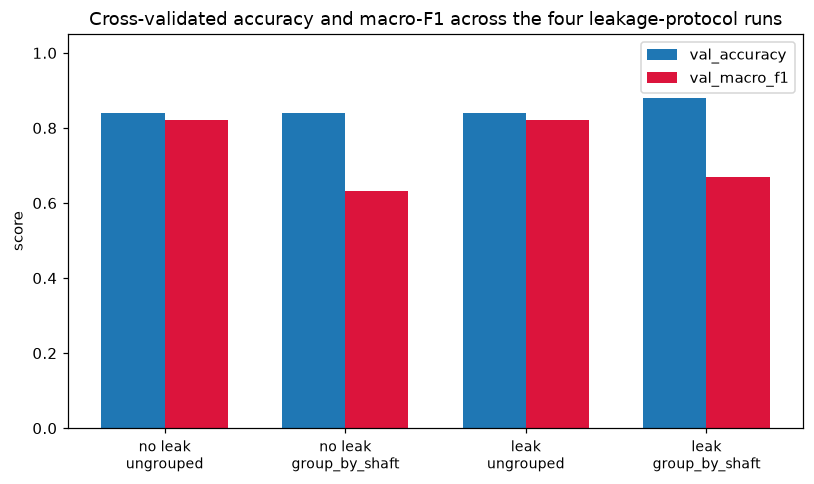

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
configs = [("no", "ungrouped"), ("no", "group_by_shaft"), ("yes", "ungrouped"), ("yes", "group_by_shaft")]
labels = ["no leak\nungrouped", "no leak\ngroup_by_shaft", "leak\nungrouped", "leak\ngroup_by_shaft"]
accuracies = [cv_runs[c][1].mean_val_accuracy for c in configs]
macro_f1s = [cv_runs[c][1].mean_val_macro_f1 for c in configs]
x = np.arange(len(configs))
width = 0.35
ax.bar(x - width / 2, accuracies, width, label="val_accuracy", color="#1f77b4")
ax.bar(x + width / 2, macro_f1s, width, label="val_macro_f1", color="crimson")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Cross-validated accuracy and macro-F1 across the four leakage-protocol runs")
ax.legend()
fig.tight_layout()
plt.show()

**Reading the four runs as they actually came out** (not as a story picked in advance): moving
from a plain `StratifiedKFold` split to `group_by_shaft=True` leaves `val_accuracy` essentially
unchanged (or higher) in both the no-leak and leak graphs, but drops `val_macro_f1` noticeably in
both &mdash; accuracy alone hides exactly the imbalanced-class effect `gnn_model.train`'s own
docstring warns about, and macro-F1 is the metric that shows it.

The artificial leaking feature itself produced a result more interesting than "it always helps":
under the **ungrouped** split it changed *nothing at all* &mdash; the leak and no-leak runs
produced the exact same out-of-fold confusion matrix, `[[5, 0], [4, 16]]`. The structural
shortcut plain `StratifiedKFold` already permits &mdash; a validation node's near-duplicate
cluster-mate sitting in train, on a graph whose edges are 81% within-cluster (Section 2) &mdash;
already saturates whatever this small graph can be pushed to on the ungrouped split, so an extra
feature correlated with cluster identity has nothing left to add there. Under
**`group_by_shaft=True`**, where that structural shortcut is explicitly closed, the leaking
feature *did* move both metrics up (accuracy 0.840 &rarr; 0.880, macro-F1 0.633 &rarr; 0.669).
That is the more uncomfortable, more informative half of this result: `group_by_shaft` grouping
closes the *structural* (same-cluster-neighbour) leak, but says nothing about a *feature* that
merely correlates with group identity (`corr(offset, per-cluster extreme count) ≈ 0.49` in
this draw, from the offsets and per-cluster extreme counts printed above) &mdash; the model can
still learn "higher onset_latency → more likely extreme" from the training clusters and
apply that learned correlation to an entirely held-out cluster's own offset value, a route
`StratifiedGroupKFold` does not, and structurally cannot, close by itself. Grouping by shaft is
necessary against the leak this section is modelled on; this run shows, honestly, that it is not
automatically sufficient against every kind.

## 4. Localizing the likely source node (Proposition 4)

Using the trained model from Section 3's `{no leak, group_by_shaft=True}` run &mdash; the
architecture (`GATv2Conv`/`SeizureGAT`) and honest evaluation protocol, with no artificial
leak &mdash; every node gets exactly one out-of-fold prediction (the prediction from whichever
fold happened to hold it out), giving a complete, non-cherry-picked read of which nodes the
model currently calls `"extreme"`.

A full cross-modal integration (Proposition 4's real target) needs a genuinely second data
modality; this notebook only has the one synthetic signal, so the "second, independent source"
here is deliberately modest: a **z-score amplitude heuristic**, calibrated purely from Section
1's own background statistics (the largest peak-`z` observed among the *background* nodes sets
the detection threshold) and computed with **no reference to the graph or the trained model at
all**. Comparing the two independent verdicts is the point, not claiming this heuristic is a
real second modality.

In [16]:
datasets_localize, cv_localize = cv_runs[("no", "group_by_shaft")]

node_pred = {}
for dataset, fold_result in zip(datasets_localize, cv_localize.fold_results):
    model = fold_result.model
    model.eval()
    with torch.no_grad():
        out = model(dataset.data.x, dataset.data.edge_index, dataset.data.edge_weight)
        pred = out.argmax(dim=1).numpy()
    val_mask = dataset.data.val_mask.numpy()
    for i, name in enumerate(dataset.node_names):
        if val_mask[i]:
            node_pred[name] = dataset.class_names[pred[i]]

gnn_flagged = {n for n, role in node_pred.items() if role == "extreme"}

background_peak_max = max(peak_z[node_names[i]] for i in background_idx)
heuristic_flagged = {n for n in node_names if peak_z[n] > background_peak_max}

true_extreme = set(EXTREME_NODES)
print(f"True extreme nodes:                         {sorted(true_extreme)}")
print(f"GNN out-of-fold 'extreme' predictions:       {sorted(gnn_flagged)}")
print(f"Heuristic flagged (peak_z > background max): {sorted(heuristic_flagged)}")
print()
print(f"Both agree on:      {sorted(gnn_flagged & heuristic_flagged)}")
print(f"GNN only:           {sorted(gnn_flagged - heuristic_flagged)}")
print(f"Heuristic only:     {sorted(heuristic_flagged - gnn_flagged)}")

True extreme nodes:                         ['C4', 'C5', 'D1', 'D5', 'E2']
GNN out-of-fold 'extreme' predictions:       ['C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D5', 'E2']
Heuristic flagged (peak_z > background max): ['C4', 'C5', 'D1', 'D5', 'E2']

Both agree on:      ['C4', 'C5', 'D1', 'D5', 'E2']
GNN only:           ['C2', 'C3', 'D2', 'D3']
Heuristic only:     []


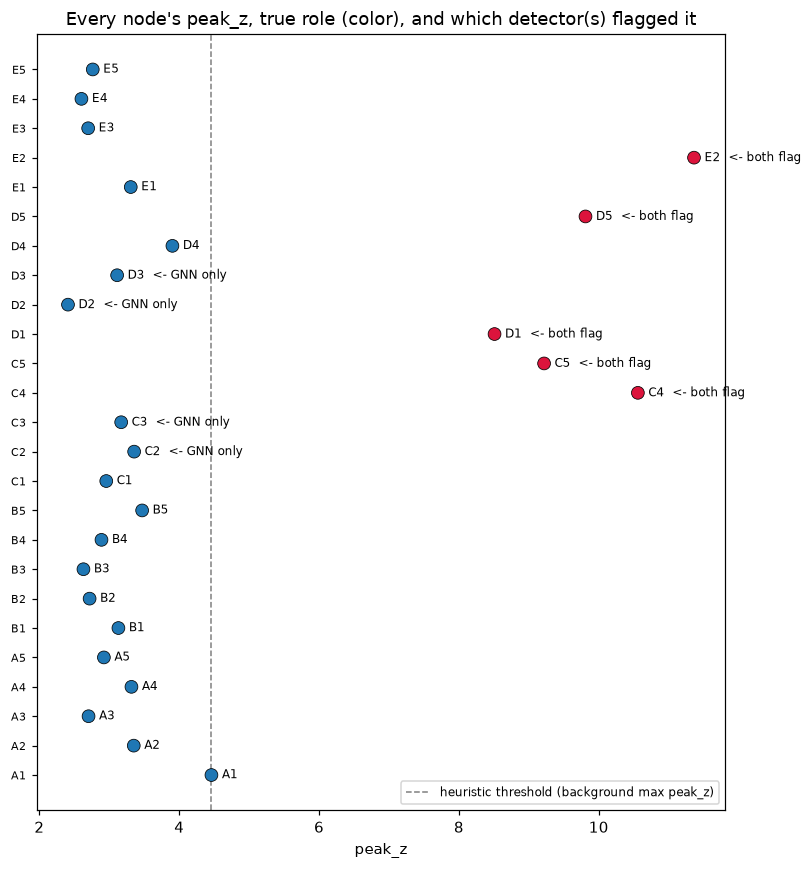

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 8))
order = sorted(node_names, key=lambda n: (node_cluster[n], n))
y = np.arange(len(order))
colors = ["crimson" if n in true_extreme else "#1f77b4" for n in order]
ax.scatter([peak_z[n] for n in order], y, color=colors, s=70, zorder=3, edgecolors="black", linewidths=0.5)
for yi, n in zip(y, order):
    marker = ""
    if n in gnn_flagged and n in heuristic_flagged:
        marker = "  <- both flag"
    elif n in gnn_flagged:
        marker = "  <- GNN only"
    elif n in heuristic_flagged:
        marker = "  <- heuristic only"
    ax.text(peak_z[n] + 0.15, yi, f"{n}{marker}", va="center", fontsize=8)
ax.axvline(background_peak_max, color="gray", linestyle="--", linewidth=1,
          label="heuristic threshold (background max peak_z)")
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=7.5)
ax.set_xlabel("peak_z"); ax.set_title("Every node's peak_z, true role (color), and which detector(s) flagged it")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

The two independent signals agree on every truly extreme node (the heuristic's threshold, by
construction, exactly separates the five extreme nodes from all twenty background ones here) but
the GNN also flags several background nodes the heuristic does not &mdash; and every one of those
extra flags sits in cluster C or D, the same two clusters that hold four of the five true extreme
nodes. That is a legible, structural disagreement rather than noise: the amplitude heuristic only
ever looks at one node's own trace, while the graph-based model's false positives are exactly the
*neighbours* of real extreme nodes in a graph whose edges are concentrated within clusters (Section
2) &mdash; it is generalizing along graph structure in a way the heuristic architecturally cannot,
for better (it might catch a genuinely borderline neighbour) and for worse (it is also the reason
`group_by_shaft` grouping in Section 3 was needed at all). Reporting where two independent methods
disagree, rather than picking the one that looks cleaner, is the same discipline the real
dissertation's Section 3.11 result applies to its own two-modality comparison.

## 5. One methodology, not four methods

Sections 1&ndash;4 above ran on **the same 25 synthetic nodes of one experiment**, start to
finish: the nodes detected as extreme in Section 1 are the same nodes whose graph was built two
ways in Section 2, the same nodes whose leakage-safe classifier was trained and evaluated in
Section 3, and the same nodes whose likely source role was cross-checked in Section 4. That is
the formal test for "a methodology" rather than "a list of results" &mdash; every component
answers a question about the *same* material the others already touched, not a fresh example
picked to flatter that one component.

**What this demonstrates convincingly**: (a) two independent classical statistics (GEV block
maxima, DFA) agree on which nodes are extreme; (b) graph construction is a real, substantive
choice &mdash; two reasonable methods on the same nodes produced substantially different graphs
(Jaccard ≈ 0.08); (c) `group_by_shaft`-style grouped cross-validation changes the honest metric
(macro-F1) even when accuracy alone hides it, on a graph built so that cluster structure is a
genuine, non-cosmetic property of the edges; (d) a trained GAT classifier and an independent
amplitude heuristic mostly agree on the true source nodes, and their disagreement is itself
structurally interpretable rather than arbitrary.

**What this does not demonstrate, and should not be read as showing**: Section 4's heuristic is
a single-feature stand-in for a genuine second modality, not a working cross-modal integration
&mdash; the real Proposition 4 claim needs an actual second data source, which this
single-signal synthetic setup does not have. Section 3's leaking feature is a deliberately
constructed synthetic case, not a reproduction of the specific real DFA/shaft-grouping incident
it is modelled on; the honest lesson it reproduces (grouped evaluation reveals a metric drop plain
k-fold hides) travelled across intact, but the exact numbers are this synthetic draw's own, not
a re-run of that real result.

Finally, the domain-neutral choice made throughout this notebook &mdash; nodes, clusters,
components, never "channels" or "seizures" &mdash; is not a stylistic accident: the same claim,
that detection, graph representation, verifiable training and localization form one architecture
rather than four separate methods, has been argued independently in the literature on computer
networks, power grids, and microservice meshes, outside biomedicine entirely, which is exactly
what grounds treating this as a software/algorithms contribution (VAK 2.3.5) rather than a purely
biomedical one.